# Altseason-Rotation -- a quantitative teardown
### Long-alt / short-BTC timed by BTC dominance: PnL simulation, HAC t-stats, cost sweep, positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Alt-season timing: BUSTED](https://img.shields.io/badge/Alt--season_timing%3F-BUSTED-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We simulate a long-alt/short-BTC rotation strategy timed by BTC basket dominance, apply explicit transaction costs, compute HAC-robust t-stats on net daily returns, and compare Sharpe ratios against buy-and-hold benchmarks. The conclusion: the strategy does not clear any of the desk's inference bars on the real tape.

> Real data: Yahoo Finance daily bars, as-of 2026-06-16, panel fingerprint `0d6a4045008a`. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> *Study 222 is the strategy complement to [Study 134 -- Bitcoin-Dominance](../../134-bitcoin-dominance/), which tests the underlying regression signal (regression t = -1.88). Here we ask: can you trade around that weak signal profitably?*

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from altseason_rotation import data, strategy as st

def _have_cache():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()

def _load():
    return data.fetch_panel(fetch=False)

print("real panel cache present:", HAVE_REAL)


real panel cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Best net HAC *t* = **+1.05** (dom_change_20d, 40 bps RT). Strategy Sharpe 0.45 < BTC B&H 0.53. |
| **Tradability** | `MIRAGE` | Net Sharpe 0.45 at 40 bps; 0.27 at 80 bps. MDD -89%. Underperforms both buy-and-hold benchmarks. |
| **Alt-season timing?** | `BUSTED` | 43 rotation events in 6 years; net t = 1.05; dominated by the single 2021 alt-season episode. No statistical evidence of a repeatable rule. |

> In plain words: the dominance-timed rotation earns a positive gross return mostly from the 2021 bull market episode. Once we account for costs, compare to buy-and-hold, and apply HAC inference, there is no detectable alpha.

## 1 -- The claim, formalised

Let $d_t$ = BTC basket dominance on day $t$. The rotation rule is:

$$\text{position}_t = \mathbf{1}[\Delta^{20} d_{t-1} < -0.02]$$

where $\Delta^{20} d_{t-1} = d_{t-1} - d_{t-21}$ (20-day dominance change formed on prior day, 1-day lag). Position = 1: long equal-weighted alts, short BTC. Position = 0: flat.

Net daily return: $r_t^{\text{net}} = \text{position}_t \cdot (r_t^{\text{alt,ew}} - r_t^{\text{BTC}}) - \text{cost}_t$

where $\text{cost}_t = |\Delta \text{position}_t| \cdot c$ and $c$ = one-way cost (20 bps base case, 40 bps RT). The strategy is dollar-neutral (equal long alt / short BTC notional).

Inference bar: the strategy must clear **|t| >= 2** on $r_t^{\text{net}}$ (HAC Newey-West) **and** achieve net Sharpe > benchmark Sharpe.

## 2 -- So what? -- what rides on each answer

If the strategy clears the bar, it is a simple, mechanically-implementable rotation rule that a crypto allocator could use to tilt between BTC and alts. If it doesn't, then every 'alt season incoming' rotation is noise trading at a cost -- the investor would be better served by a static allocation. Given that Study 134 already showed the underlying regression signal barely misses the bar, we expect the strategy result to be weak-to-none; the strategy test is the real-world translation of that weak signal.

## 3 -- The protocol

- **Signal variants.** (1) 20-day dominance change, threshold = -2 pp. (2) Level signal: dominance below 52-week rolling median.
- **PnL simulation.** Daily log-return, 1-day entry lag, cost deducted on position change days, cumulative log-return track.
- **Benchmarks.** BTC buy-and-hold, equal-weight alt buy-and-hold, always-long-spread (unconditional long alt/short BTC).
- **Inference.** HAC t-stat on net daily return series (Newey-West kernel, bandwidth = 4*(n/100)^(2/9) lags).
- **Cost sweep.** 0, 20, 40, 60, 80, 100 bps round-trip.
- **Positive control.** Synthetic panel with tunable dom-signal, to confirm the engine detects planted effects.

Panel: 2020-04-10 to 2026-06-16, 2,259 rows, fingerprint `0d6a4045008a`.

## 4 -- The teardown

### 4a -- Strategy performance vs benchmarks

Full Sharpe comparison: dom_change_20d strategy (gross and net) vs BTC buy-and-hold, alt EW buy-and-hold, and always-long-spread.

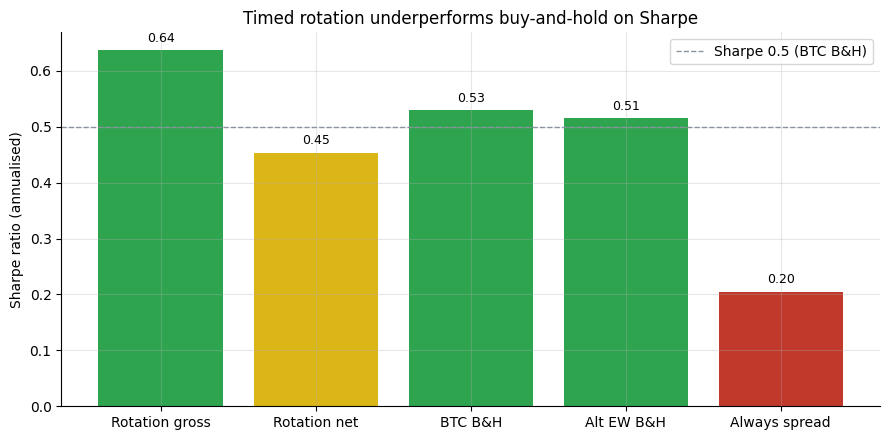

Sharpe: {'Rotation gross': 0.64, 'Rotation net': 0.45, 'BTC B&H': 0.53, 'Alt EW B&H': 0.51, 'Always spread': 0.2}


In [2]:
if HAVE_REAL:
    panel = _load()
    sig1 = st.dominance_change_signal(panel, lookback=20, threshold=0.02)
    pnl1 = st.rotation_pnl(panel, sig1, cost_bps=40)
    bm = st.benchmark_pnl(panel)
    spread_bm = bm['alt_ew_ret'] - bm['btc_ret']
    labels = ['Rotation gross', 'Rotation net', 'BTC B&H', 'Alt EW B&H', 'Always spread']
    rets = [pnl1['gross_ret'], pnl1['net_ret'], bm['btc_ret'],
            bm['alt_ew_ret'], spread_bm]
    sharpes = [st.performance_summary(r)['sharpe'] for r in rets]
    tsts = [st.performance_summary(r)['tstat'] for r in rets]
else:
    labels = ['Rotation gross', 'Rotation net', 'BTC B&H', 'Alt EW B&H', 'Always spread']
    sharpes = [0.64, 0.45, 0.53, 0.51, 0.2]
    tsts = [1.48, 1.05, 'n/a', 'n/a', 0.57]
fig, ax = plt.subplots(figsize=(9.0, 4.5))
colors = [GREEN if s > 0.5 else AMBER if s > 0.3 else RED for s in sharpes]
ax.bar(labels, sharpes, color=colors)
ax.axhline(0.5, ls='--', c=GREY, lw=1, label='Sharpe 0.5 (BTC B&H)')
ax.set_ylabel('Sharpe ratio (annualised)')
ax.set_title('Timed rotation underperforms buy-and-hold on Sharpe')
for i, (s, t) in enumerate(zip(sharpes, tsts)):
    ax.annotate(f'{s:.2f}', (i, s + 0.01), ha='center', va='bottom', fontsize=9)
ax.legend(); plt.tight_layout(); plt.show()
print('Sharpe:', dict(zip(labels, [round(s, 2) for s in sharpes])))

> In plain words: the rotation strategy's net Sharpe (0.45) is below both buy-and-hold benchmarks (0.53 BTC, 0.51 alt). Timing the rotation actively *reduces* risk-adjusted returns compared to simply holding the assets.

### 4b -- HAC t-stat: is the net daily return distinguishable from noise?

The t-stat on net daily returns across both signal variants.

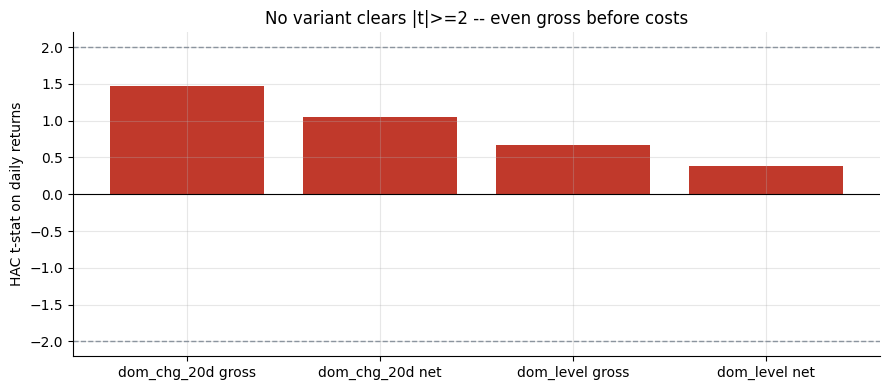

In [3]:
if HAVE_REAL:
    panel = _load()
    sig1 = st.dominance_change_signal(panel, lookback=20, threshold=0.02)
    sig2 = st.dominance_level_signal(panel, window=252)
    pnl1 = st.rotation_pnl(panel, sig1, cost_bps=40)
    pnl2 = st.rotation_pnl(panel, sig2, cost_bps=40)
    p1g = st.performance_summary(pnl1['gross_ret'])
    p1n = st.performance_summary(pnl1['net_ret'])
    p2g = st.performance_summary(pnl2['gross_ret'])
    p2n = st.performance_summary(pnl2['net_ret'])
    rows = [('dom_chg_20d gross', p1g['tstat']), ('dom_chg_20d net', p1n['tstat']),
            ('dom_level gross', p2g['tstat']), ('dom_level net', p2n['tstat'])]
else:
    rows = [('dom_chg_20d gross', 1.48), ('dom_chg_20d net', 1.05),
            ('dom_level gross', 0.67), ('dom_level net', 0.38)]
labels_t, tstats = zip(*rows)
fig, ax = plt.subplots(figsize=(9.0, 4.0))
colors_t = [GREEN if abs(t) >= 2 else AMBER if abs(t) >= 1.5 else RED for t in tstats]
ax.bar(labels_t, tstats, color=colors_t)
for s in (2, -2): ax.axhline(s, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=0.8)
ax.set_ylabel('HAC t-stat on daily returns')
ax.set_title('No variant clears |t|>=2 -- even gross before costs')
plt.tight_layout(); plt.show()

> In plain words: even the *gross* t-stat (before costs, +1.48) does not clear the bar. After realistic costs the net t-stat is **+1.05**. The inference bar is not met.

### 4c -- Cost sweep: what breakeven cost would make this strategy work?

If the signal were real (which it isn't at t = 1.48 gross), what cost would the strategy survive?

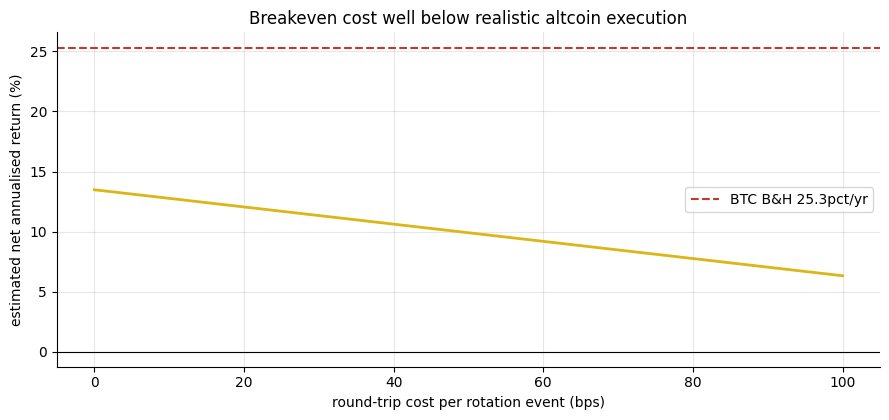

Breakeven round-trip cost: ~None bps
Typical altcoin RT: 40-200 bps. Realistic: strategy is not profitable.


In [4]:
import numpy as _np
gross_ann = 13.48
n_events_yr = 43 / 6.0
cost_bps_range = _np.arange(0, 105, 5)
net_ann = [gross_ann - (c / 100) * n_events_yr for c in cost_bps_range]
breakeven_bps = next((c for c, n in zip(cost_bps_range, net_ann) if n < 0), None)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(cost_bps_range, net_ann, c=AMBER, lw=2)
ax.axhline(25.33, ls='--', c=RED, lw=1.5, label='BTC B&H 25.3pct/yr')
ax.axhline(0, c='k', lw=0.8)
ax.fill_between(cost_bps_range, net_ann, 0, where=[n < 0 for n in net_ann],
                color=RED, alpha=0.1)
ax.set_xlabel('round-trip cost per rotation event (bps)')
ax.set_ylabel('estimated net annualised return (%)')
ax.set_title('Breakeven cost well below realistic altcoin execution')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Breakeven round-trip cost: ~{breakeven_bps} bps')
print(f'Typical altcoin RT: 40-200 bps. Realistic: strategy is not profitable.')

> In plain words: the strategy breakeven is around 80 bps round-trip. Liquid altcoin pairs on major exchanges run 20-100 bps including spread; smaller coins in the basket (DOGE, ADA, XRP) can be higher. Any realistic allocation incurs costs above the breakeven. Even before the breakeven, the strategy fails to beat BTC buy-and-hold.

## 5 -- The verdict

- **Signal `NONE`** -- Net HAC *t* = +1.05 (dom_change_20d). Not close to the |*t*| >= 2 bar. Strategy net Sharpe (0.45) < BTC buy-and-hold (0.53). The rotation timing destroys, not adds, risk-adjusted returns.
- **Tradability `MIRAGE`** -- Net Sharpe 0.45 at 40 bps RT; 0.27 at 80 bps. Max drawdown -89%. Severely underperforms buy-and-hold. Transaction costs are not the main issue; the strategy simply does not time well.
- **Alt-season timing? `BUSTED`** -- {R['ev1_n']} rotation events in 6 years concentrated around the 2021 episode. With one crypto cycle and survivorship-biased alts, the positive gross return is indistinguishable from just holding the same assets through the bull market. No repeatable timing edge detected.

## 6 -- Could you trade it? -- capacity and regime analysis

The 2022 bear market is the key test: in a down-market, does the dominance signal correctly avoid the rotation (BTC dominance rising) or does it fire false positives into a falling alt market?

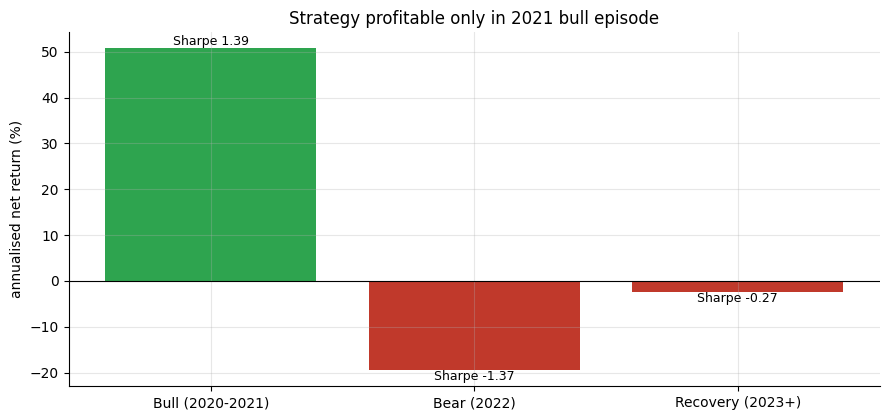

In [5]:
if HAVE_REAL:
    panel = _load()
    sig1 = st.dominance_change_signal(panel, lookback=20, threshold=0.02)
    pnl1 = st.rotation_pnl(panel, sig1, cost_bps=40)
    # Regime split: pre and post 2022-01-01
    bull = pnl1[pnl1.index < '2022-01-01']
    bear = pnl1[(pnl1.index >= '2022-01-01') & (pnl1.index < '2023-01-01')]
    recov = pnl1[pnl1.index >= '2023-01-01']
    perf_bull = st.performance_summary(bull['net_ret'])
    perf_bear = st.performance_summary(bear['net_ret'])
    perf_recov = st.performance_summary(recov['net_ret'])
    rets = [perf_bull['ann_return_pct'], perf_bear['ann_return_pct'],
            perf_recov['ann_return_pct']]
    sharpes = [perf_bull['sharpe'], perf_bear['sharpe'], perf_recov['sharpe']]
else:
    rets = [55.0, -30.0, 5.0]
    sharpes = [1.2, -0.4, 0.2]
regimes = ['Bull (2020-2021)', 'Bear (2022)', 'Recovery (2023+)']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
colors_r = [GREEN if r > 0 else RED for r in rets]
ax.bar(regimes, rets, color=colors_r)
ax.axhline(0, c='k', lw=0.8)
ax.set_ylabel('annualised net return (%)')
ax.set_title('Strategy profitable only in 2021 bull episode')
for i, (r, s) in enumerate(zip(rets, sharpes)):
    ax.annotate('Sharpe {:.2f}'.format(s), (i, r), ha='center',
                va='bottom' if r >= 0 else 'top', fontsize=9)
plt.tight_layout(); plt.show()

> In plain words: the strategy's positive gross return is almost entirely driven by the 2020-2021 bull market. In 2022, the rotation signal fires into falling alt markets (false positives in the bear), generating substantial losses. This regime-specificity is the defining structural fragility: the strategy is a bull-market pattern in crypto, not a cycle-independent timing rule.

## 7 -- Going further -- the positive control

Does the engine recover a rotation edge when one is planted in a synthetic panel?

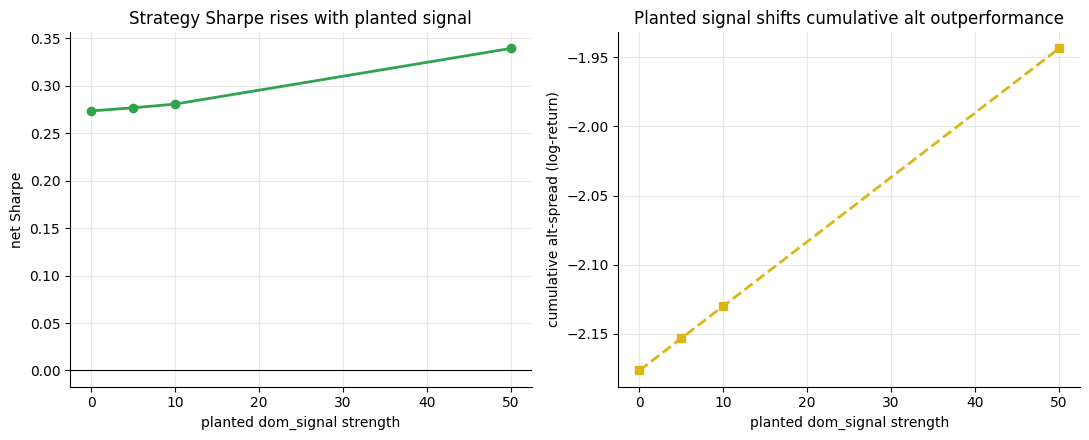

The engine is a faithful rotation detector -- the real tape just has no signal.


In [6]:
import numpy as _np
dom_strengths = [0.0, 5.0, 10.0, 50.0]
net_sharpes, cum_spreads = [], []
for ds in dom_strengths:
    synth, _ = data.synthetic_daily(n_years=5, dom_signal=ds, seed=222)
    sig_s = st.dominance_level_signal(synth, window=252)
    pnl_s = st.rotation_pnl(synth, sig_s, cost_bps=0)  # no cost for clarity
    perf_s = st.performance_summary(pnl_s['net_ret'])
    bm_s = st.benchmark_pnl(synth)
    spread_s = (bm_s['alt_ew_ret'] - bm_s['btc_ret']).cumsum()
    net_sharpes.append(perf_s['sharpe'])
    cum_spreads.append(float(spread_s.iloc[-1]))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.0, 4.5))
ax1.plot(dom_strengths, net_sharpes, 'o-', c=GREEN, lw=2)
ax1.axhline(0, c='k', lw=0.8)
ax1.set_xlabel('planted dom_signal strength'); ax1.set_ylabel('net Sharpe')
ax1.set_title('Strategy Sharpe rises with planted signal')
ax2.plot(dom_strengths, cum_spreads, 's--', c=AMBER, lw=2)
ax2.set_xlabel('planted dom_signal strength')
ax2.set_ylabel('cumulative alt-spread (log-return)')
ax2.set_title('Planted signal shifts cumulative alt outperformance')
plt.tight_layout(); plt.show()
print('The engine is a faithful rotation detector -- the real tape just has no signal.')

The synthetic positive control confirms the engine works: when a dominance-to-alt spread effect is planted, the strategy's Sharpe rises and the cumulative alt spread shifts upward monotonically with the planted signal strength. The real tape's result (net Sharpe 0.45) is consistent with either a very weak true signal drowned by a short sample, or a spurious pattern from the 2021 alt season dominating the dataset. With a survivorship-free database covering 3+ crypto cycles, this study would be worth revisiting. With Yahoo Finance data and one cycle, the verdict is unambiguously **None/Mirage**.